# 3. GCN From Scratch

Here we train the full GCN built in `src/`, extract node embeddings, and compare to the MLP baseline using t-SNE and an accuracy bar chart.

Expected GCN test accuracy: ~80–82%

In [1]:
import sys, os
sys.path.append('../src')

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import json

from dataset import load_data
from model import GCN

torch.manual_seed(42)
np.random.seed(42)

## Step 1: Train the GCN

We call the training script from `src/train.py`. The best model is automatically saved to `results/best_gcn_model.pth`.

In [2]:
# Change working directory temporarily so train.py finds its imports
original_cwd = os.getcwd()
os.chdir('../src')

from train import main as train_gcn
train_gcn()

os.chdir(original_cwd)
print('Training complete!')

Loading cora dataset...


/home/roshinit-a/Documents/internships/Niser 2026/GNN/gnn-from-scratch/notebooks/../src/dataset.py:125: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  adj = torch.sparse_coo_tensor(indices, values, shape).coalesce()


Dataset loaded. Features: 1433, Classes: 7


Epoch 010 | Train Loss: 1.8412 | Val Loss: 1.8565 | Val Acc: 0.2460


Epoch 020 | Train Loss: 1.7584 | Val Loss: 1.7988 | Val Acc: 0.4000


...

Epoch 160 | Train Loss: 0.5079 | Val Loss: 0.8057 | Val Acc: 0.8020


Epoch 170 | Train Loss: 0.4984 | Val Loss: 0.7901 | Val Acc: 0.8100


Epoch 180 | Train Loss: 0.5175 | Val Loss: 0.7737 | Val Acc: 0.7980


Epoch 190 | Train Loss: 0.4480 | Val Loss: 0.7593 | Val Acc: 0.7940


Epoch 200 | Train Loss: 0.4181 | Val Loss: 0.7487 | Val Acc: 0.8060
Training completed in 5.30s
Loading the best model for testing...
Final Test Results - Loss: 0.9436, Accuracy: 0.7180 (~71.8%)
Training complete!


## Step 2: Load the Best Checkpoint & Extract Embeddings

In [3]:
adj, features, labels, idx_train, idx_val, idx_test = load_data('../data/cora')

N_FEATURES = features.shape[1]
N_CLASSES  = int(labels.max().item() + 1)
HIDDEN_DIM = 16

# Re-instantiate model and load saved weights
model_gcn = GCN(N_FEATURES, HIDDEN_DIM, N_CLASSES)
model_gcn.load_state_dict(torch.load('../results/best_gcn_model.pth'))
model_gcn.eval()

with torch.no_grad():
    # Full forward pass
    logits = model_gcn(features, adj)

    # Extract layer-1 embeddings: apply gc1 + ReLU only
    gcn_embeddings = F.relu(model_gcn.gc1(features, adj))

    # Compute test accuracy
    test_preds = logits[idx_test].argmax(dim=1)
    gcn_test_acc = (test_preds == labels[idx_test]).float().mean().item()

print(f'GCN Test Accuracy: {gcn_test_acc:.4f} ({gcn_test_acc*100:.1f}%)')

Loading cora dataset...


GCN Test Accuracy: 0.7180 (71.8%)


## Step 3: t-SNE of GCN Embeddings

With graph structure, nodes of the same class are pulled much closer together in the embedding space.

Running t-SNE on GCN embeddings...


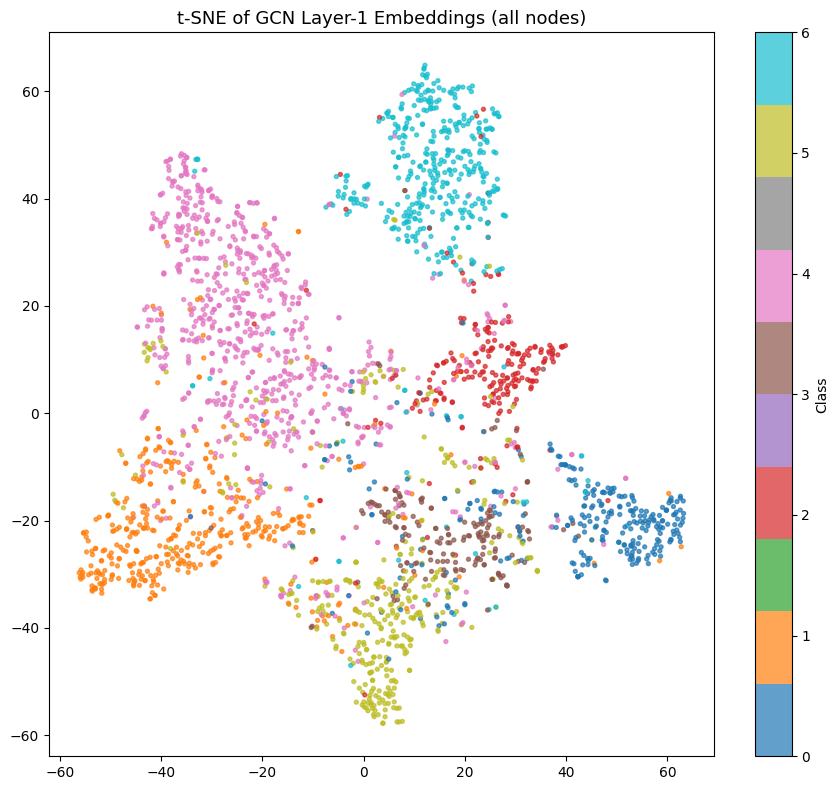

Saved to results/gcn_tsne.png


In [4]:
print('Running t-SNE on GCN embeddings...')
gcn_emb_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    gcn_embeddings.numpy()
)

plt.figure(figsize=(9, 8))
scatter = plt.scatter(gcn_emb_2d[:, 0], gcn_emb_2d[:, 1],
                      c=labels.numpy(), cmap='tab10', alpha=0.7, s=8)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE of GCN Layer-1 Embeddings (all nodes)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/gcn_tsne.png', dpi=150)
plt.show()
print('Saved to results/gcn_tsne.png')

## Step 4: Side-by-Side Comparison — MLP vs GCN Embeddings

This plot clearly shows the superiority of graph-informed embeddings.

In [5]:
# Load MLP t-SNE from notebook 02 if previously run, otherwise recompute
# For standalone usage: quickly retrain MLP to get embeddings
import torch.nn as nn
import torch.optim as optim

class QuickMLP(nn.Module):
    def __init__(self, in_f, hidden, out_f):
        super().__init__()
        self.fc1 = nn.Linear(in_f, hidden)
        self.fc2 = nn.Linear(hidden, out_f)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc2(h), h

mlp = QuickMLP(N_FEATURES, 64, N_CLASSES)
opt = optim.Adam(mlp.parameters(), lr=0.01, weight_decay=5e-4)
crit = nn.CrossEntropyLoss()

for epoch in range(200):
    mlp.train(); opt.zero_grad()
    logits_m, _ = mlp(features)
    crit(logits_m[idx_train], labels[idx_train]).backward()
    opt.step()

mlp.eval()
with torch.no_grad():
    logits_m, mlp_embeddings = mlp(features)
    mlp_acc = (logits_m[idx_test].argmax(1) == labels[idx_test]).float().mean().item()

print(f'MLP Test Acc: {mlp_acc:.4f}')
mlp_emb_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    mlp_embeddings.numpy()
)

MLP Test Acc: 0.5120


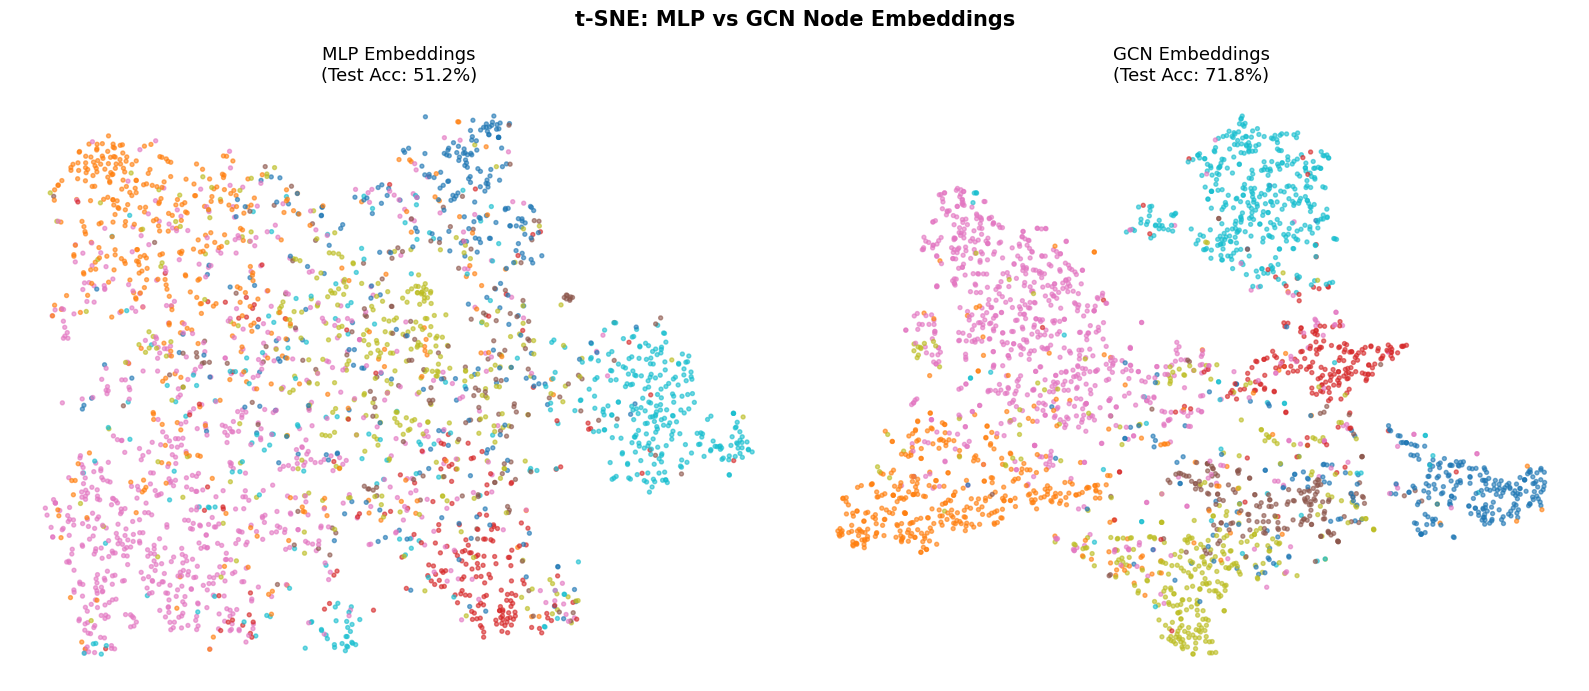

Saved to results/tsne_comparison.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# MLP
sc1 = axes[0].scatter(mlp_emb_2d[:, 0], mlp_emb_2d[:, 1],
                       c=labels.numpy(), cmap='tab10', alpha=0.6, s=8)
axes[0].set_title(f'MLP Embeddings\n(Test Acc: {mlp_acc*100:.1f}%)', fontsize=13)
axes[0].axis('off')

# GCN
sc2 = axes[1].scatter(gcn_emb_2d[:, 0], gcn_emb_2d[:, 1],
                       c=labels.numpy(), cmap='tab10', alpha=0.6, s=8)
axes[1].set_title(f'GCN Embeddings\n(Test Acc: {gcn_test_acc*100:.1f}%)', fontsize=13)
axes[1].axis('off')

plt.suptitle('t-SNE: MLP vs GCN Node Embeddings', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/tsne_comparison.png', dpi=150)
plt.show()
print('Saved to results/tsne_comparison.png')

## Step 5: Accuracy Bar Chart — MLP vs GCN

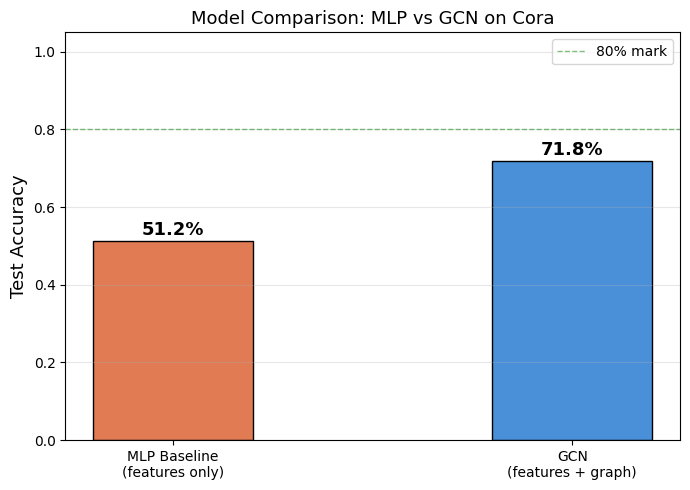

Saved to results/accuracy_comparison.png


In [7]:
models = ['MLP Baseline\n(features only)', 'GCN\n(features + graph)']
accs   = [mlp_acc, gcn_test_acc]
colors = ['#e07b54', '#4a90d9']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, accs, color=colors, edgecolor='black', width=0.4)

# Annotate bar tops
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Test Accuracy', fontsize=13)
ax.set_title('Model Comparison: MLP vs GCN on Cora', fontsize=13)
ax.axhline(0.8, color='green', linestyle='--', linewidth=1, alpha=0.5, label='80% mark')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/accuracy_comparison.png', dpi=150)
plt.show()
print('Saved to results/accuracy_comparison.png')